# Planner Internalization Experiment (Config A: Plan-only) — 日本語システムプロンプト版

> **Variant**: このノートブックは system prompt（planner への指示プリアンブル）のみを日本語化した派生実験です。入力質問・ゴールドプラン・学習データ・評価指標は英語版と同一です。W&B は同一プロジェクト `hpml-asset-ops` に `ja` タグ / `data-ablation-ja` グループで相乗りします。

**Goal**: Fine-tune Gemma 4 E4B on **planning data only** (no tool-knowledge examples) so it canproduce correct MCP tool-use plans **without tool descriptions in the prompt** (blind mode),and inspect its generated plans directly.

## Scope of this trimmed notebook

| Section | What |
|---------|------|
| **0. Setup & Data Audit** | Load data, detect contamination, build clean 80/20 split |
| **1. Understand the Data** | Plan format, blind vs informed prompts |
| **2. Baseline Evaluation** | Kept for reference only, commented out (not needed for Config A) |
| **3. Config A Training** | Train on planning-only data, evaluate blind AT-F1, inspect generations |

Removed from the original notebook: Gemini LLM-as-judge, LoRA/quantization ablation, catastrophicforgetting check, training profiling — none are needed to reproduce Config A.


In [1]:
#!pip install -q -U transformers peft trl accelerate bitsandbytes
#!pip install -q -U datasets pandas matplotlib seaborn scikit-learn
#!pip install -q -U sentencepiece protobuf wandb

In [2]:
import os, re, gc, json, math, time, random, warnings, inspect
from copy import deepcopy
from pathlib import Path
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import wandb
from dotenv import load_dotenv

load_dotenv()  # reads HF_TOKEN / WANDB_API_KEY etc. from a .env file into os.environ

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    GPU_MEM_GB = props.total_memory / 1e9
    print(f"gpu: {torch.cuda.get_device_name(0)} ({GPU_MEM_GB:.1f} GB)")
else:
    GPU_MEM_GB = 0

# ── Section timer ─────────────────────────────────────────────────────────
_section_times = {}
_section_start = None
_current_section = None

def start_timer(section_name):
    global _section_start, _current_section
    _current_section = section_name
    _section_start = time.time()
    print(f"\n{'>'*3} Starting: {section_name}")

def stop_timer():
    global _section_start, _current_section
    if _section_start is None:
        return
    elapsed = time.time() - _section_start
    _section_times[_current_section] = elapsed
    m, s = divmod(elapsed, 60)
    print(f"{'<'*3} {_current_section}: {int(m)}m {s:.0f}s")
    _section_start = None

def print_timing_summary():
    """Print timing summary and estimate full-run time from light-mode timings."""
    print("\n" + "="*70)
    print("TIMING SUMMARY")
    print("="*70)
    total = 0
    for section, elapsed in _section_times.items():
        m, s = divmod(elapsed, 60)
        print(f"  {section:45s} {int(m):3d}m {s:04.1f}s")
        total += elapsed
    m, s = divmod(total, 60)
    h, m = divmod(int(m), 60)
    print(f"  {'TOTAL':45s} {h}h {m}m {s:.0f}s")

    if LIGHT_MODE:
        # Estimate full-run time based on scaling factors
        print(f"\n  --- FULL RUN ESTIMATE ---")
        scale = {}
        full_eval = 30
        full_epochs = 3
        full_mcq = 100
        light_eval = MAX_EVAL_SCENARIOS
        light_mcq = MCQ_N_MMLU + MCQ_N_ARC + MCQ_N_HELLA

        for section, elapsed in _section_times.items():
            if "Train" in section or "ablation" in section.lower():
                scale[section] = elapsed * 30
            else:
                scale[section] = elapsed * 5

        est_total = sum(scale.values())
        h, rem = divmod(int(est_total), 3600)
        m, s = divmod(rem, 60)
        for section, est in scale.items():
            em, es = divmod(est, 60)
            print(f"  {section:45s} ~{int(em):3d}m {es:04.1f}s")
        print(f"  {'ESTIMATED FULL TOTAL':45s} ~{h}h {m}m {s}s")

/home/kumakura/hpml-2026-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
gpu: NVIDIA A100-SXM4-40GB (42.4 GB)


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
MODEL_ID = "google/gemma-4-E2B-it"
# MODEL_ID = "google/gemma-4-E4B-it"

def _get_secret(name):
    """Read a secret from environment variables."""
    return os.environ.get(name, "")

HF_TOKEN = _get_secret("HF_TOKEN")
WANDB_API_KEY = _get_secret("WANDB_API_KEY")
WANDB_ENTITY = _get_secret("WANDB_ENTITY")

REPO_URL = "https://github.com/kumakuraa/hpml-2026-project.git"
REPO_DIR = Path("/home/kumakura/hpml-2026-project/")
# ── 言語バリアント (ja): 出力・W&B を英語版と分離するための識別子 ──────────
RUN_VARIANT = "ja"
OUTPUT_DIR = REPO_DIR / Path(f"output_{RUN_VARIANT}/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── LIGHT MODE ────────────────────────────────────────────────────────────
# Set True to do a fast smoke-test (~1 min per cell). Set False for full run.
LIGHT_MODE = False

if LIGHT_MODE:
    MAX_EVAL_SCENARIOS = 3        # only 3 test scenarios per eval
    DEFAULT_EPOCHS = 1            # single epoch
    MAX_TRAIN_EXAMPLES = 50       # cap training data
    MAX_NEW_TOKENS = 256
    EARLY_STOPPING_PATIENCE = 2
    RANK_SWEEP = [8, 16]          # only 2 ranks
    MCQ_N_MMLU, MCQ_N_ARC, MCQ_N_HELLA = 6, 4, 4  # 14 MCQ total
    print("LIGHT MODE: fast smoke-test (set LIGHT_MODE=False for full run)")
else:
    MAX_EVAL_SCENARIOS = 30
    DEFAULT_EPOCHS = 2
    MAX_TRAIN_EXAMPLES = None     # use all
    MAX_NEW_TOKENS = 512
    EARLY_STOPPING_PATIENCE = 2
    RANK_SWEEP = [8, 16, 32, 64]
    MCQ_N_MMLU, MCQ_N_ARC, MCQ_N_HELLA = 40, 30, 30  # 100 MCQ total
    print("FULL MODE: complete experiment")

# ── Adaptive GPU settings ─────────────────────────────────────────────────
if GPU_MEM_GB > 60:
    MAX_SEQ_LENGTH = 1024
    PER_DEVICE_BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 1
else:
    MAX_SEQ_LENGTH = 512
    PER_DEVICE_BATCH_SIZE = 4
    GRADIENT_ACCUMULATION_STEPS = 2

# ── Training defaults (overridden per experiment) ─────────────────────────
DEFAULT_LR = 2e-4
DEFAULT_LORA_R = 16
DEFAULT_LORA_ALPHA = 32
LORA_DROPOUT = 0.05
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01

# ── Eval settings ─────────────────────────────────────────────────────────
TEMPERATURE = 0.1
TOP_P = 0.9
MIN_LOSS_DELTA = 0.005

# ── W&B configuration ────────────────────────────────────────────────────
WANDB_PROJECT = "hpml-asset-ops"
# WANDB_ENTITY = "group20"
WANDB_RUN_MODE = "debug" if LIGHT_MODE else "full-run"

# Login to W&B
if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
    print(f"W&B logged in (project={WANDB_PROJECT}, mode={WANDB_RUN_MODE})")
else:
    print("W&B: no WANDB_API_KEY set — logging disabled")

# ── W&B helpers ──────────────────────────────────────────────────────────

def wb_run_tags():
    """Common tags for all runs."""
    tags = [WANDB_RUN_MODE, MODEL_ID.split("/")[-1], RUN_VARIANT]
    if torch.cuda.is_available():
        tags.append(torch.cuda.get_device_name(0).replace(" ", "-"))
    return tags

def wb_base_config():
    """Base config dict logged with every W&B run."""
    return {
        "model_id": MODEL_ID,
        "light_mode": LIGHT_MODE,
        "max_seq_length": MAX_SEQ_LENGTH,
        "batch_size": PER_DEVICE_BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "max_eval_scenarios": MAX_EVAL_SCENARIOS,
        "default_epochs": DEFAULT_EPOCHS,
        "max_train_examples": MAX_TRAIN_EXAMPLES,
        "lr": DEFAULT_LR,
        "lora_r": DEFAULT_LORA_R,
        "lora_alpha": DEFAULT_LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "temperature": TEMPERATURE,
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
        "gpu_mem_gb": GPU_MEM_GB,
    }

def wb_init(run_name, group, job_type, extra_config=None):
    """Initialize a W&B run with standard naming. Returns the run or None."""
    if not WANDB_API_KEY:
        return None
    config = wb_base_config()
    if extra_config:
        config.update(extra_config)
    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{'[DEBUG] ' if LIGHT_MODE else ''}{run_name}",
        group=group,
        job_type=job_type,
        tags=wb_run_tags() + ([job_type] if job_type else []),
        config=config,
        reinit=True,
    )
    return run

def wb_finish():
    """Finish current W&B run if active."""
    if wandb.run is not None:
        wandb.finish()

def wb_log_metrics_table(table_name, df, run=None):
    """Log a pandas DataFrame as a W&B Table."""
    if wandb.run is None and run is None:
        return
    tbl = wandb.Table(dataframe=df.reset_index(drop=True) if hasattr(df, 'reset_index') else df)
    wandb.log({table_name: tbl})

def wb_log_figure(fig_name, fig=None):
    """Log a matplotlib figure to W&B."""
    if wandb.run is None:
        return
    wandb.log({fig_name: wandb.Image(fig or plt.gcf())})

print(json.dumps({
    "model": MODEL_ID, "light_mode": LIGHT_MODE,
    "max_seq_length": MAX_SEQ_LENGTH, "batch_size": PER_DEVICE_BATCH_SIZE,
    "max_eval_scenarios": MAX_EVAL_SCENARIOS, "epochs": DEFAULT_EPOCHS,
    "hf_token_set": bool(HF_TOKEN),
    "wandb_key_set": bool(WANDB_API_KEY),
    "wandb_mode": WANDB_RUN_MODE,
}, indent=2))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/kumakura/.netrc


FULL MODE: complete experiment


wandb: Currently logged in as: kumapo to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B logged in (project=hpml-asset-ops, mode=full-run)
{
  "model": "google/gemma-4-E2B-it",
  "light_mode": false,
  "max_seq_length": 512,
  "batch_size": 4,
  "max_eval_scenarios": 30,
  "epochs": 2,
  "hf_token_set": true,
  "wandb_key_set": true,
  "wandb_mode": "full-run"
}


In [4]:
# ── Load repo and datasets ────────────────────────────────────────────────
if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("repo already present:", REPO_DIR)

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

datasets_dir = REPO_DIR / "benchmark" / "generate_data" / "datasets"
ds_tool = load_jsonl(datasets_dir / "tool_knowledge.jsonl")
ds_plan = load_jsonl(datasets_dir / "planning.jsonl")
ds_exec = load_jsonl(datasets_dir / "execution.jsonl")

gold_path = REPO_DIR / "benchmark" / "baseline_tests" / "gemini_flash_informed_results.json"
with open(gold_path) as f:
    gold_plans_raw = json.load(f)
gold_by_id = {g["id"]: g for g in gold_plans_raw if g.get("plan_steps", 0) > 0}

print(f"Datasets: tool={len(ds_tool)}, plan={len(ds_plan)}, exec={len(ds_exec)}")
print(f"Gold plans: {len(gold_by_id)}")

repo already present: /home/kumakura/hpml-2026-project
Datasets: tool=307, plan=1589, exec=120
Gold plans: 148


## 0. Data Audit & Clean Split

The training data (`planning.jsonl`) was generated from the **same** 152 HF scenarios used for evaluation. We check for contamination and build a clean 80/20 split at the scenario level.

In [5]:
# ── Load AssetOpsBench scenarios (needed for train/test split below) ──────
from datasets import load_dataset as hf_load_dataset

hf_ds = hf_load_dataset("ibm-research/AssetOpsBench", "scenarios")
hf_scenarios = [dict(row) for row in hf_ds["train"]]
print(f"Loaded {len(hf_scenarios)} scenarios from ibm-research/AssetOpsBench")


Loaded 152 scenarios from ibm-research/AssetOpsBench


In [6]:
# ── Pattern-aware stratified 80/20 split ──────────────────────────────────
# Each scenario gets a "pattern" = (type, tools_used, step_count).
# We split so train and test share the same patterns where possible.

for sc in hf_scenarios:
    g = gold_by_id.get(sc["id"], {})
    sc["tools"] = tuple(sorted(g.get("tools_used", [])))
    sc["steps"] = g.get("plan_steps", 0)
    sc["agents"] = tuple(sorted(g.get("agents_used", [])))
    sc["pattern"] = (sc["type"], sc["tools"], sc["steps"])
    sc["complexity"] = "simple" if sc["steps"] <= 2 else "complex"
    sc["gold_plan"] = g.get("response", "")
    sc["gold_prompt"] = g.get("prompt", sc["text"])

by_stratum = defaultdict(lambda: defaultdict(list))
for sc in hf_scenarios:
    by_stratum[(sc["type"], sc["complexity"])][sc["pattern"]].append(sc)

test_scenarios, train_scenarios = [], []
for stratum, pattern_groups in by_stratum.items():
    all_in = [sc for group in pattern_groups.values() for sc in group]
    n_test = max(1, round(len(all_in) * 0.20))

    test_pool, remaining = [], []
    for pattern, members in pattern_groups.items():
        random.shuffle(members)
        if len(members) >= 2:
            test_pool.append(members[0])
            remaining.extend(members[1:])
        else:
            remaining.extend(members)

    random.shuffle(test_pool)
    actual_test = test_pool[:n_test]
    remaining.extend(test_pool[n_test:])

    if len(actual_test) < n_test:
        shortfall = n_test - len(actual_test)
        random.shuffle(remaining)
        actual_test.extend(remaining[:shortfall])
        remaining = remaining[shortfall:]

    for sc in actual_test:
        sc["test_kind"] = "seen_pattern" if any(
            sc["pattern"] == t["pattern"] for t in remaining
        ) else "novel_pattern"

    test_scenarios.extend(actual_test)
    train_scenarios.extend(remaining)

# Cap test to MAX_EVAL_SCENARIOS
if len(test_scenarios) > MAX_EVAL_SCENARIOS:
    random.shuffle(test_scenarios)
    test_scenarios = test_scenarios[:MAX_EVAL_SCENARIOS]

test_ids = {sc["id"] for sc in test_scenarios}
test_questions_set = {sc["text"].strip().lower() for sc in test_scenarios}
test_prompts_set = {sc["gold_prompt"].strip().lower() for sc in test_scenarios}
all_test_qs = test_questions_set | test_prompts_set

# Filter training data: remove anything from test scenarios
def is_contaminated(question, threshold=0.8):
    q = question.strip().lower()
    if q in all_test_qs:
        return True
    for tq in all_test_qs:
        if SequenceMatcher(None, q, tq).ratio() > threshold:
            return True
    return False

clean_plan = [ex for ex in ds_plan if not is_contaminated(ex["messages"][0]["content"])]
clean_exec = [ex for ex in ds_exec if not is_contaminated(ex["messages"][0]["content"])]
clean_tool = ds_tool  # no scenario-specific questions

# Validate
train_qs = {ex["messages"][0]["content"].strip().lower() for ex in clean_plan + clean_exec}
leaked = train_qs & all_test_qs
assert len(leaked) == 0, f"LEAKAGE: {len(leaked)} questions in both train and test!"

n_seen = sum(1 for s in test_scenarios if s.get("test_kind") == "seen_pattern")
n_novel = sum(1 for s in test_scenarios if s.get("test_kind") == "novel_pattern")
type_dist = Counter(s["type"] for s in test_scenarios)

print(f"Train scenarios: {len(train_scenarios)} | Test scenarios: {len(test_scenarios)}")
print(f"Test breakdown: {n_seen} seen-pattern, {n_novel} novel-pattern")
print(f"Test type dist: {dict(type_dist)}")
print(f"Clean train: {len(clean_tool)} tool + {len(clean_plan)} plan + {len(clean_exec)} exec")
print(f"Leakage check: PASSED (0 leaked)")

Train scenarios: 122 | Test scenarios: 30
Test breakdown: 29 seen-pattern, 1 novel-pattern
Test type dist: {'IoT': 4, 'FMSR': 4, 'TSFM': 5, 'Workorder': 9, 'multiagent': 8}
Clean train: 307 tool + 1526 plan + 79 exec
Leakage check: PASSED (0 leaked)


## 1. Understand the Data

Three training datasets, each teaching a different aspect of tool knowledge:
- **tool_knowledge** (307): What agents/tools exist, who owns them, their arguments, hard negatives
- **planning** (1,589): Question → structured plan (#Task/#Agent/#Tool/#Args/#Dependency)
- **execution** (120): Question → plan + execution trace with resolved arguments

## 1. Evaluation Infrastructure

We define:
1. **Plan parser** — extract structured steps from model output
2. **Structural metrics** — agent-tool F1, arg key F1 (AT-F1 is the headline metric)
3. **Informed vs Blind prompts** — the key comparison


In [7]:
# ── Prompts ────────────────────────────────────────────────────────────────

TOOL_DESCRIPTIONS = """Available Agents and Tools:

IoTAgent:
  - sites(): List all available IoT sites
  - assets(site_name): List assets at a site
  - sensors(site_name, asset_id): List sensors for an asset
  - history(site_name, asset_id, start, final=None): Get sensor history

FMSRAgent:
  - get_failure_modes(asset_name): Get failure modes for an asset
  - get_failure_mode_sensor_mapping(asset_name, failure_modes, sensors): Map failure modes to sensors

TSFMAgent:
  - get_ai_tasks(): List available AI tasks
  - get_tsfm_models(): List time-series models
  - run_tsfm_forecasting(...): Run forecasting
  - run_tsfm_finetuning(...): Fine-tune a TSFM model
  - run_tsad(...): Run anomaly detection
  - run_integrated_tsad(...): Run integrated anomaly detection

Utilities:
  - json_reader(file_name): Read a JSON file
  - current_date_time(): Get current date/time
  - current_time_english(): Get current time in English

WorkOrderAgent:
  - get_work_orders(asset_name): Get work orders
  - get_preventive_work_orders(asset_name): Get preventive work orders
  - get_corrective_work_orders(asset_name): Get corrective work orders
  - get_events(asset_name): Get events
  - get_failure_codes(asset_name): Get failure codes
  - get_work_order_distribution(asset_name): Get work order distribution
  - predict_next_work_order(asset_name): Predict next work order
  - analyze_alert_to_failure(asset_name): Analyze alert-to-failure patterns
"""

INFORMED_PROMPT = """あなたは産業用アセット運用の専門プランナーです。質問と利用可能なツールが与えられるので、構造化されたプランを作成してください。

{tool_descriptions}

出力フォーマット（1ステップにつき1ブロック）:
#Task1: <説明>
#Agent1: <エージェント名>
#Tool1: <ツール名>
#Args1: {{"arg": "value"}}
#Dependency1: None
#ExpectedOutput1: <期待される出力>

ルール: リストにあるエージェント/ツールのみ使用すること。プランは簡潔に。依存関係には {{step_N}} を使用してください。

質問: {question}
"""

BLIND_PROMPT = """あなたは産業用アセット運用の専門プランナーです。構造化されたプランを作成してください。

出力フォーマット（1ステップにつき1ブロック）:
#Task1: <説明>
#Agent1: <エージェント名>
#Tool1: <ツール名>
#Args1: {{"arg": "value"}}
#Dependency1: None
#ExpectedOutput1: <期待される出力>

ルール: プランは簡潔に。依存関係には {{step_N}} を使用してください。

質問: {question}
"""

def print_exact_token_counts(tokenizer):
    """Print exact token counts using the model's tokenizer (call after model is loaded)."""
    sample_q = "What IoT sites are available?"
    informed_text = INFORMED_PROMPT.format(tool_descriptions=TOOL_DESCRIPTIONS, question=sample_q)
    blind_text = BLIND_PROMPT.format(question=sample_q)
    n_informed = len(tokenizer.encode(informed_text))
    n_blind = len(tokenizer.encode(blind_text))
    print(f"Exact token counts (sample: '{sample_q}'):")
    print(f"  Informed prompt: {n_informed} tokens")
    print(f"  Blind prompt:    {n_blind} tokens")
    print(f"  Tool description overhead: {n_informed - n_blind} tokens ({100*(n_informed - n_blind)/n_informed:.0f}%)")
    return n_informed, n_blind

print("Prompts defined. Token counts will be printed after model loading.")

Prompts defined. Token counts will be printed after model loading.


In [8]:
# ── Plan parser & structural metrics ──────────────────────────────────────
VALID_AGENTS = {"IoTAgent", "FMSRAgent", "TSFMAgent", "Utilities", "WorkOrderAgent", "VibrationAgent", "none"}
VALID_TOOLS = {
    "sites", "assets", "sensors", "history",
    "get_failure_modes", "get_failure_mode_sensor_mapping",
    "get_ai_tasks", "get_tsfm_models", "run_tsfm_forecasting",
    "run_tsfm_finetuning", "run_tsad", "run_integrated_tsad",
    "json_reader", "current_date_time", "current_time_english",
    "get_work_orders", "get_preventive_work_orders", "get_corrective_work_orders",
    "get_events", "get_failure_codes", "get_work_order_distribution",
    "predict_next_work_order", "analyze_alert_to_failure", "none",
}

def parse_plan(text):
    steps = []
    if not text:
        return steps
    for block in re.split(r"(?=#Task\d+:)", text):
        block = block.strip()
        task_m = re.search(r"#Task(\d+):\s*(.*)", block)
        agent_m = re.search(r"#Agent\d+:\s*(\S+)", block)
        tool_m = re.search(r"#Tool\d+:\s*(\S+)", block)
        args_m = re.search(r"#Args\d+:\s*(.*)", block)
        dep_m = re.search(r"#Dependency\d+:\s*(.*)", block)
        if not task_m:
            continue
        args_raw = args_m.group(1).strip() if args_m else "{}"
        try:
            args = json.loads(args_raw)
        except Exception:
            args = {}
        steps.append({
            "step": int(task_m.group(1)),
            "task": task_m.group(2).strip(),
            "agent": agent_m.group(1).strip() if agent_m else "",
            "tool": tool_m.group(1).strip().rstrip("()") if tool_m else "",
            "args": args,
            "dependency": dep_m.group(1).strip() if dep_m else "None",
        })
    return steps

def set_f1(gold, pred):
    g, p = set(gold), set(pred)
    if not g and not p: return 1.0
    if not g or not p: return 0.0
    tp = len(g & p)
    prec, rec = tp / len(p), tp / len(g)
    return 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0

def evaluate_plan(pred_text, gold_text):
    pred_steps, gold_steps = parse_plan(pred_text), parse_plan(gold_text)
    pred_pairs = [(s["agent"], s["tool"]) for s in pred_steps if s["tool"]]
    gold_pairs = [(s["agent"], s["tool"]) for s in gold_steps if s["tool"]]

    gold_args = {(s["agent"], s["tool"]): s["args"] for s in gold_steps if s["args"]}
    key_scores = []
    for s in pred_steps:
        k = (s["agent"], s["tool"])
        if k in gold_args:
            key_scores.append(set_f1(gold_args[k].keys(), s["args"].keys() if isinstance(s["args"], dict) else []))

    return {
        "has_format": "#Task" in (pred_text or "") and "#Agent" in (pred_text or ""),
        "num_steps": len(pred_steps),
        "gold_steps": len(gold_steps),
        "agent_tool_f1": set_f1(gold_pairs, pred_pairs),
        "arg_key_f1": float(np.mean(key_scores)) if key_scores else 0.0,
        "valid_agents": sum(1 for s in pred_steps if s["agent"] in VALID_AGENTS),
        "valid_tools": sum(1 for s in pred_steps if s["tool"] in VALID_TOOLS),
        "total_steps_pred": len(pred_steps),
    }

def summarize_metrics(results):
    if not results: return {}
    return {
        "n": len(results),
        "format_%": 100 * np.mean([r["has_format"] for r in results]),
        "AT-F1": float(np.mean([r["agent_tool_f1"] for r in results])),
        "ArgKey-F1": float(np.mean([r["arg_key_f1"] for r in results])),
        "agent_%": sum(r["valid_agents"] for r in results) / max(sum(r["total_steps_pred"] for r in results), 1),
        "tool_%": sum(r["valid_tools"] for r in results) / max(sum(r["total_steps_pred"] for r in results), 1),
    }

print("Evaluation functions defined.")


Evaluation functions defined.


In [9]:
# ── Model loading, inference, and evaluation runner ───────────────────────
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, EarlyStoppingCallback
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from datasets import Dataset

def load_base_model(load_in_8bit=True, load_in_4bit=False):
    """Load Gemma 4 E4B with quantization."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if load_in_4bit:
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                  bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
        label = "4-bit NF4"
    elif load_in_8bit:
        bnb = BitsAndBytesConfig(load_in_8bit=True)
        label = "8-bit"
    else:
        bnb = None
        label = "bf16 (no quant)"

    print(f"Loading {MODEL_ID} [{label}]...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
    model_kwargs = dict(device_map="auto", dtype=torch.bfloat16, token=HF_TOKEN, attn_implementation="eager")
    if bnb:
        model_kwargs["quantization_config"] = bnb
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id
    return model, tokenizer

def setup_lora(base_model, r=DEFAULT_LORA_R, alpha=DEFAULT_LORA_ALPHA):
    peft_model = prepare_model_for_kbit_training(base_model)
    config = LoraConfig(r=r, lora_alpha=alpha, lora_dropout=LORA_DROPOUT,
                        target_modules="all-linear", bias="none", task_type=TaskType.CAUSAL_LM)
    peft_model = get_peft_model(peft_model, config)
    trainable, total = peft_model.get_nb_trainable_parameters()
    print(f"LoRA r={r}, alpha={alpha} -> trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return peft_model

def generate_plan(model, tokenizer, question, prompt_template, tool_desc=""):
    """Generate a plan from a prompt template."""
    if "{tool_descriptions}" in prompt_template:
        prompt = prompt_template.format(tool_descriptions=tool_desc, question=question)
    else:
        prompt = prompt_template.format(question=question)

    chat = [{"role": "user", "content": prompt}]
    tok = tokenizer.apply_chat_template(chat, return_tensors="pt", add_generation_prompt=True, return_dict=True)
    input_ids = tok["input_ids"].to(model.device)
    attn = tok["attention_mask"].to(model.device)
    input_len = input_ids.shape[1]

    with torch.no_grad():
        # ── prob_dist エラー対策 (RuntimeError: prob_dist must be 1 or 2 dim) ──────
        # PEFT (LoraModel) は logits_to_keep を明示的なシグネチャに持たないため、
        # transformers 側の `_supports_logits_to_keep()` 判定が False になり、
        # generate() が logits_to_keep を自動設定してくれない。すると Gemma4 の
        # prepare_inputs_for_generation() 自身のデフォルト値 `None` がそのまま
        # forward() に渡り、`hidden_states[:, None, :]` として解釈されて新しい軸が
        # 挿入されてしまい (numpyのnewaxisと同じ意味)、logits が4次元になって
        # 最終的に torch.multinomial に3次元の probs が渡りクラッシュする。
        # generate() 呼び出し時に明示的に logits_to_keep=1 を渡すことで回避する。
        out = model.generate(input_ids=input_ids, attention_mask=attn,
                             max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE,
                             top_p=TOP_P, do_sample=True, logits_to_keep=1,
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    generated = tokenizer.decode(out[0][input_len:], skip_special_tokens=True)
    return generated, input_len

def run_eval(model, tokenizer, scenarios, prompt_template, mode_name, tool_desc=""):
    """Run plan generation + structural eval on test scenarios."""
    results = []
    for sc in tqdm(scenarios[:MAX_EVAL_SCENARIOS], desc=mode_name):
        q = sc.get("gold_prompt", sc["text"])
        gold = sc["gold_plan"]
        gen, n_input = generate_plan(model, tokenizer, q, prompt_template, tool_desc)
        metrics = evaluate_plan(gen, gold)
        metrics.update({"id": sc["id"], "type": sc["type"], "question": q,
                        "gold_plan": gold, "generated": gen,
                        "input_tokens": n_input, "mode": mode_name,
                        "test_kind": sc.get("test_kind", "")})
        results.append(metrics)
    return results

def wb_log_eval_table(results, table_name="eval_predictions"):
    """Log a W&B Table with generated vs gold plans and structural metrics."""
    if wandb.run is None or not results:
        return
    rows = []
    for r in results:
        rows.append({
            "id": r["id"],
            "type": r["type"],
            "mode": r.get("mode", ""),
            "question": r["question"][:300],
            "gold_plan": r.get("gold_plan", "")[:500],
            "generated_plan": r.get("generated", "")[:500],
            "AT-F1": r["agent_tool_f1"],
            "ArgKey-F1": r["arg_key_f1"],
            "has_format": r["has_format"],
            "num_steps_pred": r["num_steps"],
            "num_steps_gold": r["gold_steps"],
            "input_tokens": r["input_tokens"],
        })

    wb_log_metrics_table(table_name, pd.DataFrame(rows))

    # Log aggregate metrics
    summary = summarize_metrics(results)
    for k, v in summary.items():
        if isinstance(v, (int, float)):
            wandb.log({f"eval/{k}": v})

print("Model / training / eval infrastructure ready.")

Model / training / eval infrastructure ready.


In [10]:
# ── Training function with early stopping + W&B logging ──────────────────

def train_model(peft_model, tokenizer, train_data, eval_data=None, output_dir="./out",
                epochs=DEFAULT_EPOCHS, lr=DEFAULT_LR, run_name="train",
                wb_group=None, wb_extra_config=None):
    """SFT training with early stopping and W&B logging.

    Training curves (train_loss, eval_loss, learning_rate) are automatically
    streamed to W&B via HuggingFace's built-in integration (report_to='wandb').
    After training, an explicit overlay chart of train vs eval loss is logged.
    """
    os.makedirs(output_dir, exist_ok=True)
    train_ds = Dataset.from_list(train_data)
    eval_ds = Dataset.from_list(eval_data) if eval_data else None

    total_steps = max(1, len(train_ds) * epochs // max(PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS, 1))
    warmup_steps = max(1, int(total_steps * WARMUP_RATIO))

    # Adaptive logging/eval frequency: log every step if <20 steps, else ~10 logs per run
    logging_steps = max(1, min(10, total_steps // 10))
    eval_steps = max(1, total_steps // max(epochs * 4, 4))  # ~4 evals per epoch for better curves

    # ── W&B run init (creates a run that SFTTrainer will adopt) ───────────
    wb_run = None
    report_to = "none"
    if WANDB_API_KEY:
        wb_config = wb_base_config()
        wb_config.update({
            "run_name": run_name,
            "train_examples": len(train_ds),
            "eval_examples": len(eval_ds) if eval_ds else 0,
            "epochs": epochs,
            "lr": lr,
            "total_steps_est": total_steps,
            "warmup_steps": warmup_steps,
            "logging_steps": logging_steps,
            "eval_steps": eval_steps,
        })
        if wb_extra_config:
            wb_config.update(wb_extra_config)

        wb_run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"{'[DEBUG] ' if LIGHT_MODE else ''}{run_name}",
            group=wb_group or "training",
            job_type="train",
            tags=wb_run_tags() + ["train", wb_group or "training"],
            config=wb_config,
            reinit=True,
        )
        report_to = "wandb"

    sft_kwargs = dict(
        output_dir=output_dir, run_name=run_name,
        num_train_epochs=epochs,
        per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=lr, lr_scheduler_type="cosine",
        warmup_steps=warmup_steps, weight_decay=WEIGHT_DECAY,
        bf16=True, logging_steps=logging_steps,
        eval_strategy="steps" if eval_ds else "no",
        eval_steps=eval_steps if eval_ds else None,
        save_strategy="steps", save_steps=eval_steps,
        save_total_limit=2,
        load_best_model_at_end=bool(eval_ds),
        metric_for_best_model="eval_loss" if eval_ds else None,
        greater_is_better=False if eval_ds else None,
        report_to=report_to, seed=SEED,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        remove_unused_columns=False,
    )
    if "max_seq_length" in inspect.signature(SFTConfig.__init__).parameters:
        sft_kwargs["max_seq_length"] = MAX_SEQ_LENGTH
    sft_config = SFTConfig(**sft_kwargs)

    callbacks = []
    if eval_ds:
        callbacks.append(EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=MIN_LOSS_DELTA,
        ))

    trainer_kwargs = {"model": peft_model, "args": sft_config,
                      "train_dataset": train_ds, "processing_class": tokenizer,
                      "callbacks": callbacks}
    if eval_ds:
        trainer_kwargs["eval_dataset"] = eval_ds
    if "max_seq_length" in inspect.signature(SFTTrainer.__init__).parameters and "max_seq_length" not in sft_kwargs:
        trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

    trainer = SFTTrainer(**trainer_kwargs)
    trainer.train()

    # Extract training history
    history = trainer.state.log_history
    train_losses = [(h["step"], h["loss"]) for h in history if "loss" in h]
    eval_losses = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]
    learning_rates = [(h["step"], h["learning_rate"]) for h in history if "learning_rate" in h]
    stopped_early = trainer.state.global_step < total_steps and len(eval_losses) > EARLY_STOPPING_PATIENCE

    # ── Log learning curves + summary to W&B ──────────────────────────────
    if wb_run:
        final_train_loss = train_losses[-1][1] if train_losses else None
        final_eval_loss = eval_losses[-1][1] if eval_losses else None
        wandb.summary["final_train_loss"] = final_train_loss
        wandb.summary["final_eval_loss"] = final_eval_loss
        wandb.summary["stopped_early"] = stopped_early
        wandb.summary["actual_steps"] = trainer.state.global_step

        # Log raw loss data as W&B Table
        loss_rows = []
        for step, loss in train_losses:
            loss_rows.append({"step": step, "train_loss": loss, "eval_loss": None})
        for step, loss in eval_losses:
            found = False
            for row in loss_rows:
                if row["step"] == step:
                    row["eval_loss"] = loss
                    found = True
                    break
            if not found:
                loss_rows.append({"step": step, "train_loss": None, "eval_loss": loss})
        loss_rows.sort(key=lambda r: r["step"])
        if loss_rows:
            wb_log_metrics_table("learning_curve_data", pd.DataFrame(loss_rows))

        # Plot train vs eval loss overlay
        if train_losses or eval_losses:
            fig, ax1 = plt.subplots(figsize=(10, 5))
            if train_losses:
                t_steps, t_vals = zip(*train_losses)
                ax1.plot(t_steps, t_vals, "b-o", alpha=0.7, label="Train Loss", linewidth=1.5, markersize=4)
            if eval_losses:
                e_steps, e_vals = zip(*eval_losses)
                ax1.plot(e_steps, e_vals, "r-s", label="Eval Loss", linewidth=2, markersize=6)
            ax1.set_xlabel("Step")
            ax1.set_ylabel("Loss")
            ax1.set_title(f"Learning Curves: {run_name}")
            ax1.legend(loc="upper left")
            ax1.grid(True, alpha=0.3)

            if learning_rates:
                ax2 = ax1.twinx()
                lr_steps, lr_vals = zip(*learning_rates)
                ax2.plot(lr_steps, lr_vals, "g--", alpha=0.4, label="Learning Rate", linewidth=1)
                ax2.set_ylabel("Learning Rate", color="green")
                ax2.tick_params(axis="y", labelcolor="green")
                ax2.legend(loc="upper right")

            if stopped_early:
                ax1.axvline(x=trainer.state.global_step, color="orange", linestyle="--", alpha=0.7)

            plt.tight_layout()
            wb_log_figure("learning_curves")
            plt.close(fig)

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    print(f"Training complete: {trainer.state.global_step}/{total_steps} steps"
          + (f" [logging every {logging_steps} steps, eval every {eval_steps} steps]")
          + (" [EARLY STOPPED]" if stopped_early else ""))
    return trainer, {"train_losses": train_losses, "eval_losses": eval_losses,
                     "stopped_early": stopped_early, "total_steps": trainer.state.global_step}

print("Training function with early stopping + W&B logging defined.")

Training function with early stopping + W&B logging defined.


## 2. Baseline Evaluation (Reference only — commented out below, not needed for Config A)

In [11]:
# ── Baseline evaluation (commented out — not needed for Config A, kept for reference) ──
# base_model = None  # placeholder so del base_model doesn't crash in quant cell
# print("Base model loading SKIPPED — hardcoded results from run_2 and run_3.")

In [12]:
# ── Baseline informed eval (commented out — not needed for Config A, kept for reference) ──
# baseline_informed_summary = {
#     "n": 30, "format_%": 100.0, "AT-F1": 0.470, "ArgKey-F1": 0.600,
#     "agent_%": 0.850, "tool_%": 0.903,
# }
# baseline_informed = []  # raw results not needed for downstream
# print("Baseline Informed (from run_2):", json.dumps(baseline_informed_summary, indent=2))

In [13]:
# ── Baseline blind eval (commented out — not needed for Config A, kept for reference) ──
# baseline_blind_summary = {
#     "n": 30, "format_%": 100.0, "AT-F1": 0.0, "ArgKey-F1": 0.0,
#     "agent_%": 0.0, "tool_%": 0.0,
# }
# baseline_blind = []
# print("Baseline Blind (from run_2):", json.dumps(baseline_blind_summary, indent=2))

In [14]:
# ── Baseline comparison table (commented out — used Gemini judge + baselines, neither needed for Config A) ──
# baseline_informed_judge = [{"correctness": 2.133, "agent_routing": 3.967, "tool_selection": 2.667,
#                             "argument_quality": 2.567, "efficiency": 2.367, "dependency_correctness": 3.6}]
# baseline_blind_judge = [{"correctness": 1.2, "agent_routing": 1.1, "tool_selection": 1.0,
#                          "argument_quality": 1.333, "efficiency": 2.167, "dependency_correctness": 4.5}]
#
# baseline_df = pd.DataFrame([
#     {"mode": "Informed (upper bound)", **baseline_informed_summary,
#      "judge_n": 30, "judge_correctness": 2.133, "judge_agent_routing": 3.967,
#      "judge_tool_selection": 2.667, "judge_argument_quality": 2.567,
#      "judge_efficiency": 2.367, "judge_dependency_correctness": 3.6, "judge_overall": 2.883},
#     {"mode": "Blind (lower bound)", **baseline_blind_summary,
#      "judge_n": 30, "judge_correctness": 1.2, "judge_agent_routing": 1.1,
#      "judge_tool_selection": 1.0, "judge_argument_quality": 1.333,
#      "judge_efficiency": 2.167, "judge_dependency_correctness": 4.5, "judge_overall": 1.883},
# ])
# print("=== BASELINE COMPARISON (from run_2) ===")
# display(baseline_df.round(3))
# print("Token savings: 573 (informed) -> 139 (blind) = 434 tokens saved (76%)")
# avg_informed_tokens, avg_blind_tokens = 573, 139
# token_savings, token_pct = 434, 76

## (Reference) Config C primary training — commented out below (not needed for Config A)

In [15]:
# ── Shared data helpers ─────────────────────────────────────────────────
def msgs(examples):
    """Extract just the messages field for SFT."""
    return [{"messages": ex["messages"]} for ex in examples]

def split_train_eval(data, eval_frac=0.05):
    random.shuffle(data)
    split = max(1, int(len(data) * (1 - eval_frac)))
    return data[:split], data[split:]

def cap(data):
    """Cap training data in light mode."""
    if MAX_TRAIN_EXAMPLES and len(data) > MAX_TRAIN_EXAMPLES:
        random.shuffle(data)
        return data[:MAX_TRAIN_EXAMPLES]
    return data


In [16]:
# ── Config C primary training (commented out — not needed for Config A, kept for reference) ──
# AT-F1: 0.635, judge overall: 3.60

all_experiment_results = {}  # populated by the Config A training cell below

# all_experiment_results["Baseline Informed"] = {"structural": baseline_informed_summary,
#                                                 "judge": {"n": 30, "correctness": 2.133, "agent_routing": 3.967,
#                                                           "tool_selection": 2.667, "argument_quality": 2.567,
#                                                           "efficiency": 2.367, "dependency_correctness": 3.6, "overall": 2.883}}
# all_experiment_results["Baseline Blind"] = {"structural": baseline_blind_summary,
#                                              "judge": {"n": 30, "correctness": 1.2, "agent_routing": 1.1,
#                                                        "tool_selection": 1.0, "argument_quality": 1.333,
#                                                        "efficiency": 2.167, "dependency_correctness": 4.5, "overall": 1.883}}
#
# blind_summary = {
#     "n": 30, "format_%": 100.0, "AT-F1": 0.635, "ArgKey-F1": 0.630,
#     "agent_%": 0.975, "tool_%": 0.949,
# }
# judge_summary = {
#     "n": 30, "correctness": 2.828, "agent_routing": 4.310, "tool_selection": 3.966,
#     "argument_quality": 3.448, "efficiency": 3.241, "dependency_correctness": 4.552, "overall": 3.600,
# }
# blind_results = []  # raw results not available (will skip error analysis)
# judge_results = []
#
# best_config = "C: Tool+Plan"
# all_experiment_results[best_config] = {
#     "structural": blind_summary, "judge": judge_summary,
#     "raw_results": blind_results, "raw_judge": judge_results,
# }
#
# print(f"Primary (Tool+Plan) blind AT-F1: {blind_summary['AT-F1']:.3f}, judge overall: {judge_summary['overall']:.2f}")
# print("(Results from run_2 — training completed 654/652 steps)")

In [17]:
# ── Primary results table (commented out — compares baselines + Config C, not needed for Config A) ──
# primary_df = pd.DataFrame([
#     {"config": "Baseline Informed", **baseline_informed_summary,
#      "judge_n": 30, "judge_correctness": 2.133, "judge_agent_routing": 3.967,
#      "judge_tool_selection": 2.667, "judge_argument_quality": 2.567,
#      "judge_efficiency": 2.367, "judge_dependency_correctness": 3.6, "judge_overall": 2.883},
#     {"config": "Baseline Blind", **baseline_blind_summary,
#      "judge_n": 30, "judge_correctness": 1.2, "judge_agent_routing": 1.1,
#      "judge_tool_selection": 1.0, "judge_argument_quality": 1.333,
#      "judge_efficiency": 2.167, "judge_dependency_correctness": 4.5, "judge_overall": 1.883},
#     {"config": "Fine-tuned (Tool+Plan) Blind", **blind_summary,
#      "judge_n": 30, "judge_correctness": 2.828, "judge_agent_routing": 4.310,
#      "judge_tool_selection": 3.966, "judge_argument_quality": 3.448,
#      "judge_efficiency": 3.241, "judge_dependency_correctness": 4.552, "judge_overall": 3.600},
# ])
# print("=== PRIMARY RESULTS (from run_2) ===")
# display(primary_df.round(3))

## 3. Config A Training: Plan-only

Train on planning data only (`clean_plan`), no tool-knowledge examples. Evaluate blind-modeAT-F1 on the held-out test scenarios, then inspect generated plans directly.


In [18]:
# ── Train Config A (Plan-only) ─────────────────────────────────────────────
try:
    start_timer("Config A training (Plan-only)")

    # Load fresh base model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    base_model, tokenizer = load_base_model(load_in_8bit=True)

    # Config A: Planning only (no tool-knowledge examples)
    config_a_train, config_a_eval = split_train_eval(cap(msgs(clean_plan)))

    ablation_configs = {
        "A: Plan-only": (config_a_train, config_a_eval),
    }

    for name, data in ablation_configs.items():
        print(f"{name}: train={len(data[0])}, eval={len(data[1])}")

    for config_name, config_data in ablation_configs.items():
        print(f"\n{'='*70}\n TRAINING: {config_name}\n{'='*70}")

        try:
            train_data, eval_data = config_data
            peft_model = setup_lora(base_model)
            _, hist = train_model(peft_model, tokenizer, train_data, eval_data,
                                      str(OUTPUT_DIR / f"data_{config_name}"),
                                      run_name=config_name,
                                      wb_group="data-ablation-ja",
                                      wb_extra_config={"data_config": config_name, "lang_variant": RUN_VARIANT})

            abl_blind = run_eval(peft_model, tokenizer, test_scenarios, BLIND_PROMPT, f"{config_name} Blind")
            abl_summary = summarize_metrics(abl_blind)

            if wandb.run is not None:
                wandb.summary.update({
                    "eval/AT-F1": abl_summary.get("AT-F1", 0),
                    "eval/ArgKey-F1": abl_summary.get("ArgKey-F1", 0),
                })
                wb_log_eval_table(abl_blind, f"predictions_{config_name}")
            wb_finish()

            all_experiment_results[config_name] = {
                "structural": abl_summary,
                "raw_results": abl_blind,
            }
            print(f"{config_name} blind AT-F1: {abl_summary.get('AT-F1', 0):.3f}")

            del peft_model
        except Exception as inner_e:
            print(f"  *** {config_name} FAILED: {inner_e} ***")
            import traceback; traceback.print_exc()
            wb_finish()
            if "peft_model" in dir() and (
                not LIGHT_MODE # wont delete if debug
            ):
                del peft_model

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    stop_timer()

    # Clean up
    del base_model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

except Exception as e:
    print(f"\n*** CONFIG A TRAINING FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Starting: Config A training (Plan-only)
Loading google/gemma-4-E2B-it [8-bit]...


Loading weights: 100%|██████████| 1951/1951 [00:06<00:00, 324.92it/s] 


A: Plan-only: train=1449, eval=77

 TRAINING: A: Plan-only
LoRA r=16, alpha=32 -> trainable: 37,920,768 / 5,142,218,272 (0.74%)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Building labels for eval dataset: 100%|██████████| 77/77 [00:00<00:00, 2757.43 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
45,0.772568,0.620173,0.634753,103533.000000,0.848435
90,0.481341,0.456658,0.508336,211907.000000,0.882644
135,0.345532,0.378439,0.347189,326426.000000,0.902258
180,0.380182,0.336210,0.319706,431471.000000,0.913604
225,0.265733,0.304197,0.271050,538980.000000,0.920714
270,0.255531,0.282740,0.246818,647187.000000,0.927714
315,0.250696,0.272756,0.243975,747091.000000,0.930297
360,0.196001,0.271796,0.244621,860708.000000,0.930320
364,0.196001,0.272689,0.244413,868574.000000,0.930596


Training complete: 364/362 steps [logging every 10 steps, eval every 45 steps]


A: Plan-only Blind: 100%|██████████| 30/30 [33:17<00:00, 66.57s/it] 
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


eval/AT-F1,▁
eval/ArgKey-F1,▁
eval/agent_%,▁
eval/entropy,█▆▃▂▁▁▁▁▁
eval/format_%,▁
eval/loss,█▅▃▂▂▁▁▁▁
eval/mean_token_accuracy,▁▄▆▇▇████
eval/n,▁
eval/num_tokens,▁▂▃▄▅▆▇██
eval/runtime,▇▆▆█▅▄█▆▁
+11,...


A: Plan-only blind AT-F1: 0.520
<<< Config A training (Plan-only): 57m 39s


In [19]:
# ── Config A (Plan-only) の生成結果を目視確認 ──────────────────────────
config_a_raw = all_experiment_results.get("A: Plan-only", {}).get("raw_results", [])
if config_a_raw:
    sorted_results = sorted(config_a_raw, key=lambda r: r["agent_tool_f1"], reverse=True)

    print("=== TOP 5 PREDICTIONS (Config A: Plan-only) ===")
    for r in sorted_results[:5]:
        print(f"\n  ID={r['id']} [{r['type']}] AT-F1={r['agent_tool_f1']:.2f}")
        print(f"  Q: {r['question'][:100]}")
        print(f"  Gold:      {r['gold_plan'][:300]}")
        print(f"  Generated: {r['generated'][:300]}")

    print("\n=== BOTTOM 5 PREDICTIONS (Config A: Plan-only) ===")
    for r in sorted_results[-5:]:
        print(f"\n  ID={r['id']} [{r['type']}] AT-F1={r['agent_tool_f1']:.2f}")
        print(f"  Q: {r['question'][:100]}")
        print(f"  Gold:      {r['gold_plan'][:300]}")
        print(f"  Generated: {r['generated'][:300]}")
else:
    print("(raw_results が見つかりません — 学習セルが正常に完走したか確認してください)")

=== TOP 5 PREDICTIONS (Config A: Plan-only) ===

  ID=102 [FMSR] AT-F1=1.00
  Q: List all failure modes of asset Chiller 6.
  Gold:      #Task1: Retrieve the known failure modes for the asset "Chiller 6".
#Agent1: FMSRAgent
#Tool1: get_failure_modes
#Args1: {"asset_name": "Chiller 6"}
#Dependency1: None
#ExpectedOutput1: A list of failure modes for Chiller 6.
  Generated: #Task1: Retrieve all known failure modes for the asset "Chiller 6".
#Agent1: FMSRAgent
#Tool1: get_failure_modes
#Args1: {"asset_name": "Chiller 6"}
#Dependency1: None
#ExpectedOutput1: A list of failure modes associated with "Chiller 6".

  ID=220 [TSFM] AT-F1=1.00
  Q: Finetune a forecasting model for 'Chiller 9 Condenser Water Flow' using data in 'chiller9_finetuning
  Gold:      #Task1: Finetune a forecasting model for 'Chiller 9 Condenser Water Flow' using the provided dataset.
#Agent1: TSFMAgent
#Tool1: run_tsfm_finetuning
#Args1: {"dataset_path": "chiller9_finetuning_small.csv", "timestamp_column": "Timestamp",


=== CONFIG A RESULT (Blind Mode) ===


,config,n,format_%,AT-F1,ArgKey-F1,agent_%,tool_%
0,A: Plan-only,30,100.0,0.52,0.603,0.95,0.933



Best data config: A: Plan-only (AT-F1=0.520)


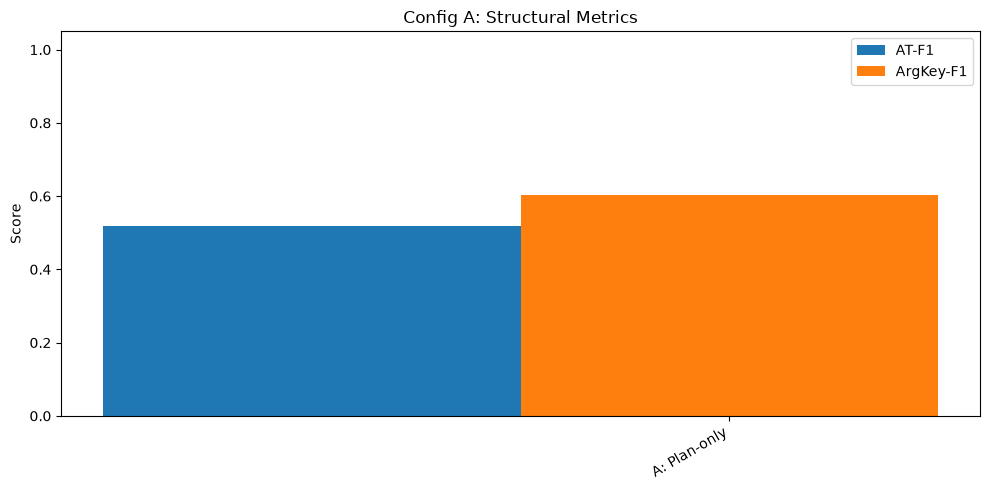

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best_data_config,A: Plan-only


In [20]:
# ── Config A results table + W&B ──────────────────────────────────────────
try:
    ablation_rows = []
    for name, res in all_experiment_results.items():
        if "Baseline" in name:
            continue
        row = {"config": name}
        row.update(res.get("structural", {}))
        ablation_rows.append(row)

    data_ablation_df = pd.DataFrame(ablation_rows)
    print("\n=== CONFIG A RESULT (Blind Mode) ===")
    display(data_ablation_df.round(3))

    # Confirm best
    ablation_best = max(ablation_rows, key=lambda r: r.get("AT-F1", 0))
    print(f"\nBest data config: {ablation_best['config']} (AT-F1={ablation_best.get('AT-F1', 0):.3f})")

    # Log to W&B
    wb_run = wb_init("data-ablation-summary", group="data-ablation", job_type="analysis")
    if wb_run:
        wb_log_metrics_table("data_ablation_comparison", data_ablation_df)
        wandb.summary["best_data_config"] = ablation_best["config"]

        # Grouped bar chart
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(data_ablation_df))
        w = 0.25
        for j, metric in enumerate(["AT-F1", "ArgKey-F1"]):
            if metric in data_ablation_df.columns:
                ax.bar(x + j * w, data_ablation_df[metric].fillna(0), w, label=metric)
        ax.set_xticks(x + w)
        ax.set_xticklabels(data_ablation_df["config"], rotation=30, ha="right")
        ax.set_ylabel("Score")
        ax.set_title("Config A: Structural Metrics")
        ax.legend()
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        wb_log_figure("data_ablation_chart")
        plt.show()

        wb_finish()
except Exception as e:
    print(f"\n*** CONFIG A SUMMARY FAILED: {e} ***\n")
    import traceback; traceback.print_exc()
    wb_finish()

## Summary

This trimmed notebook fine-tunes Gemma 4 E4B on **planning-only data** (Config A, no tool-knowledgeexamples) and evaluates blind-mode AT-F1 on held-out AssetOpsBench scenarios, with the generatedplans inspected directly (see the inspection cell after training).
